# Предсказания отклика клиента на маркетинговую кампанию

Сегодня мы попытаемся решить задачу предсказания отклика клиента на маркетинговую кампанию на открытом датасете.

Набор данных:  
https://www.kaggle.com/datasets/jackdaoud/marketing-data/data

## Импорт библиотек, загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://github.com/evgpat/datasets/raw/main/ifood_df_raw.csv')

## Exploratory Data Analysis (EDA)

При решении любой аналитической / ML задачи важно предварительно хорошо понять наши данные.
Поэтому начнем мы с проведения исследовательского анализа данных (EDA).
Это поможет нам:
* Понять структуру и содержание наших данных
* Выявить возможные проблемы с данными (пропущенные значения, дубликаты, выбросы)
* Определить основные характеристики переменных, распределение)
* Определить взаимосвязи между переменными

Посмотрим на наши данные.

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


AcceptedCmp1 — клиент принял оффер 1-й кампании (1 - да, 0 - нет)
AcceptedCmp2 — клиент принял оффер 2-й кампании (1 - да, 0 - нет)
AcceptedCmp3 — клиент принял оффер 3-й кампании (1 - да, 0 - нет)
AcceptedCmp4 — клиент принял оффер 4-й кампании (1 - да, 0 - нет)
AcceptedCmp5 — клиент принял оффер 5-й кампании (1 - да, 0 - нет)
Dt_Customer — дата, когда клиент начал пользоваться услугами компании
Complain — жаловался ли клиент в последние два года
Income — годовой доход домохозяйства
Kidhome — количество маленьких детей
Teenhome — количество детей-подростков
Year_Birth — год рождения

Траты на конкретные группы товаров за последние два года:
* MntFishProducts — рыба
* MntFruits — фрукты
* MntGoldProds — ювелирные изделия
* MntMeatProducts — мясо
* MntSweetProducts — сладости
* MntWines — вино

NumCatalogPurchases — количество покупок из каталога
NumDealsPurchases — количество покупок со скидкой
NumStorePurchases — количество покупок в физических магазинах
NumWebPurchases — количество покупок через Интернет
NumWebVisitsMonth — количество визитов на сайт за последний месяц

Recency — количество дней с последней покупки

Education — уровень образования: Basic, 2n Cycle, Graduation, Master, PhD
Marital_Status — семейное положение

Z_CostContact, Z_Revenue — служебные поля (одинаковые у всех клиентов)

**Response** — отклик на последнюю кампанию (будущая целевая переменная)

Начнем с метода  `df.info()`- посмотрим на типы столбцов, пропущенные значения и т.п.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum() # проверяем пропуски

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Видим, что столбец `Income` содержит пропуски

In [6]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


Вернемся к этой проблеме позже.

Теперь используем метод `.describe()`, чтобы посчитать основные описательные статистики для числовых столбцов

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Обратите внимание на подозрительные значения:
* минимальный `Year_Birth` — 1893 год, то есть клиенту больше 120 лет;
* максимальный `Income` — 666 666, это на порядок больше 75%-квантиля.

Скорее всего, это ошибки ввода. Вернемся к ним, когда будем готовить признаки.

In [8]:
df = df.drop(['Z_CostContact', 'Z_Revenue'], axis=1) # удаляем признаки с нулевой дисперсией

In [9]:
df.shape

(2240, 27)

Теперь посчитаем статистики для категориальных переменных:

In [10]:
df.describe(exclude='number')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,2012-08-31
freq,1127,864,12


In [11]:
df.select_dtypes(['int']).columns

Index(['ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [12]:
int_columns = ['Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

Построим распределения числовых переменных:

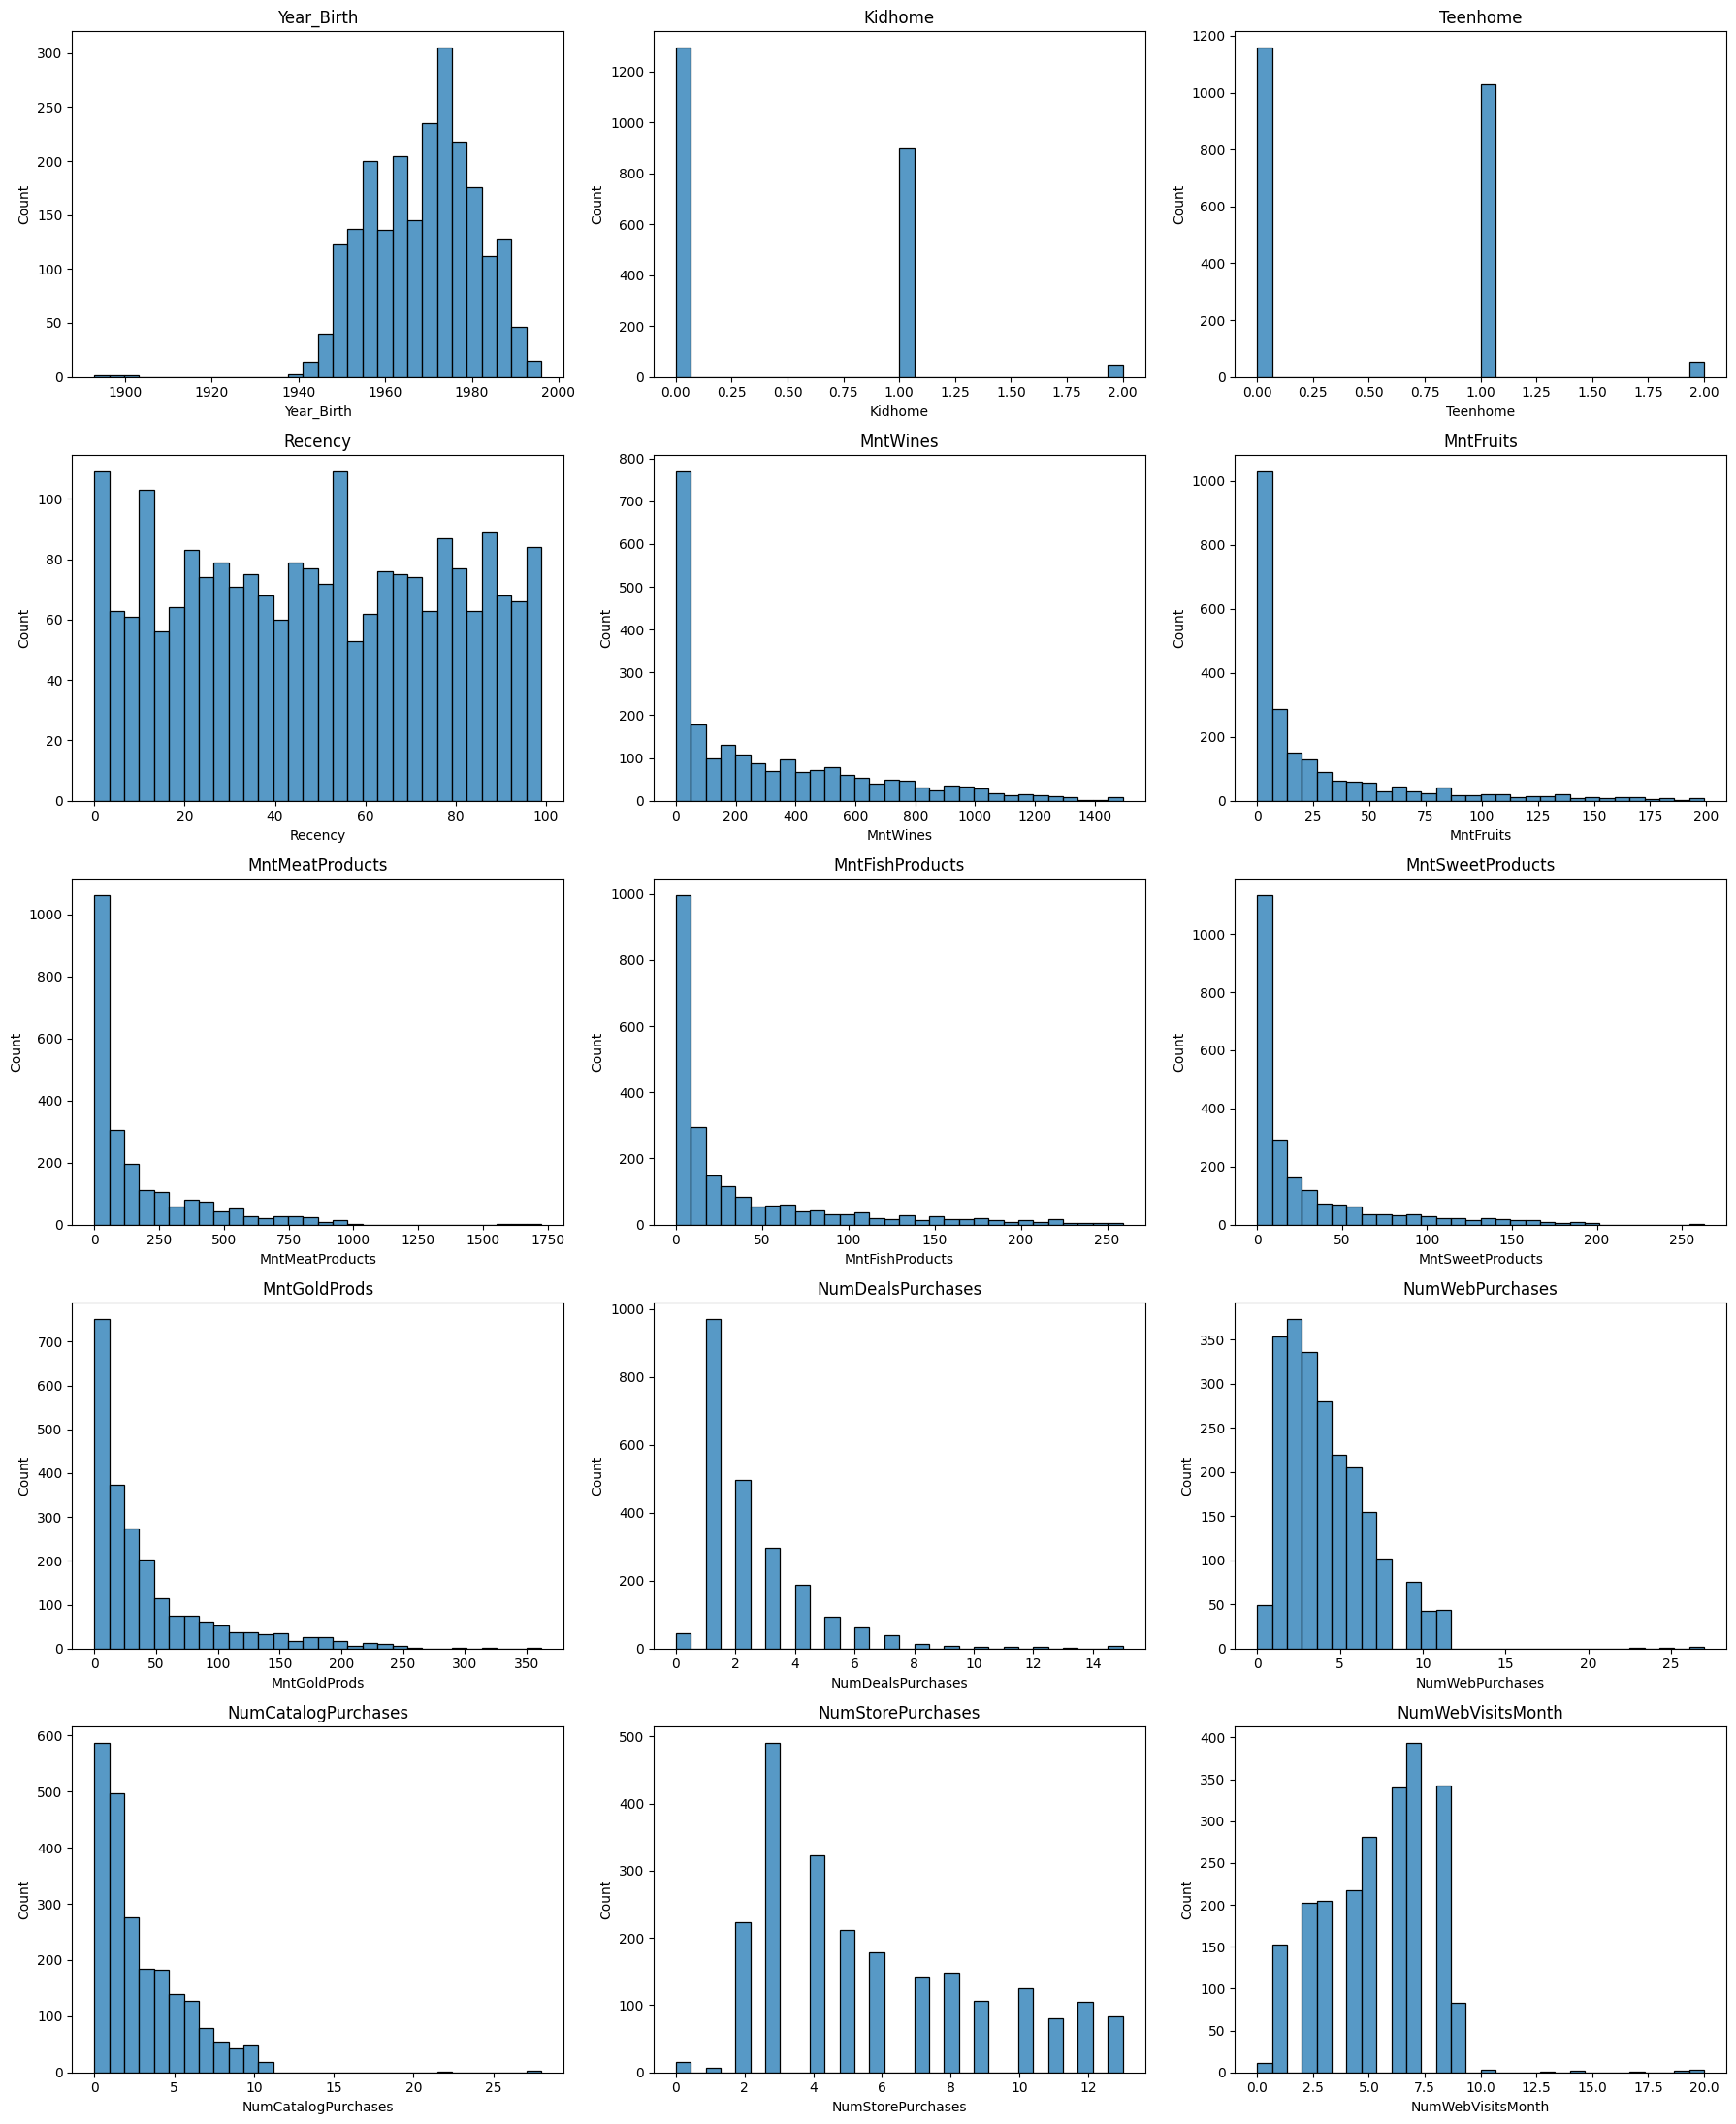

In [13]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))

for var, ax in zip(int_columns, axes.flat):
    sns.histplot(df[var], bins=30, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

Теперь давайте сравнием распределения среди групп клиентов, у которых `Response = 1` и у которых `Response = 0`

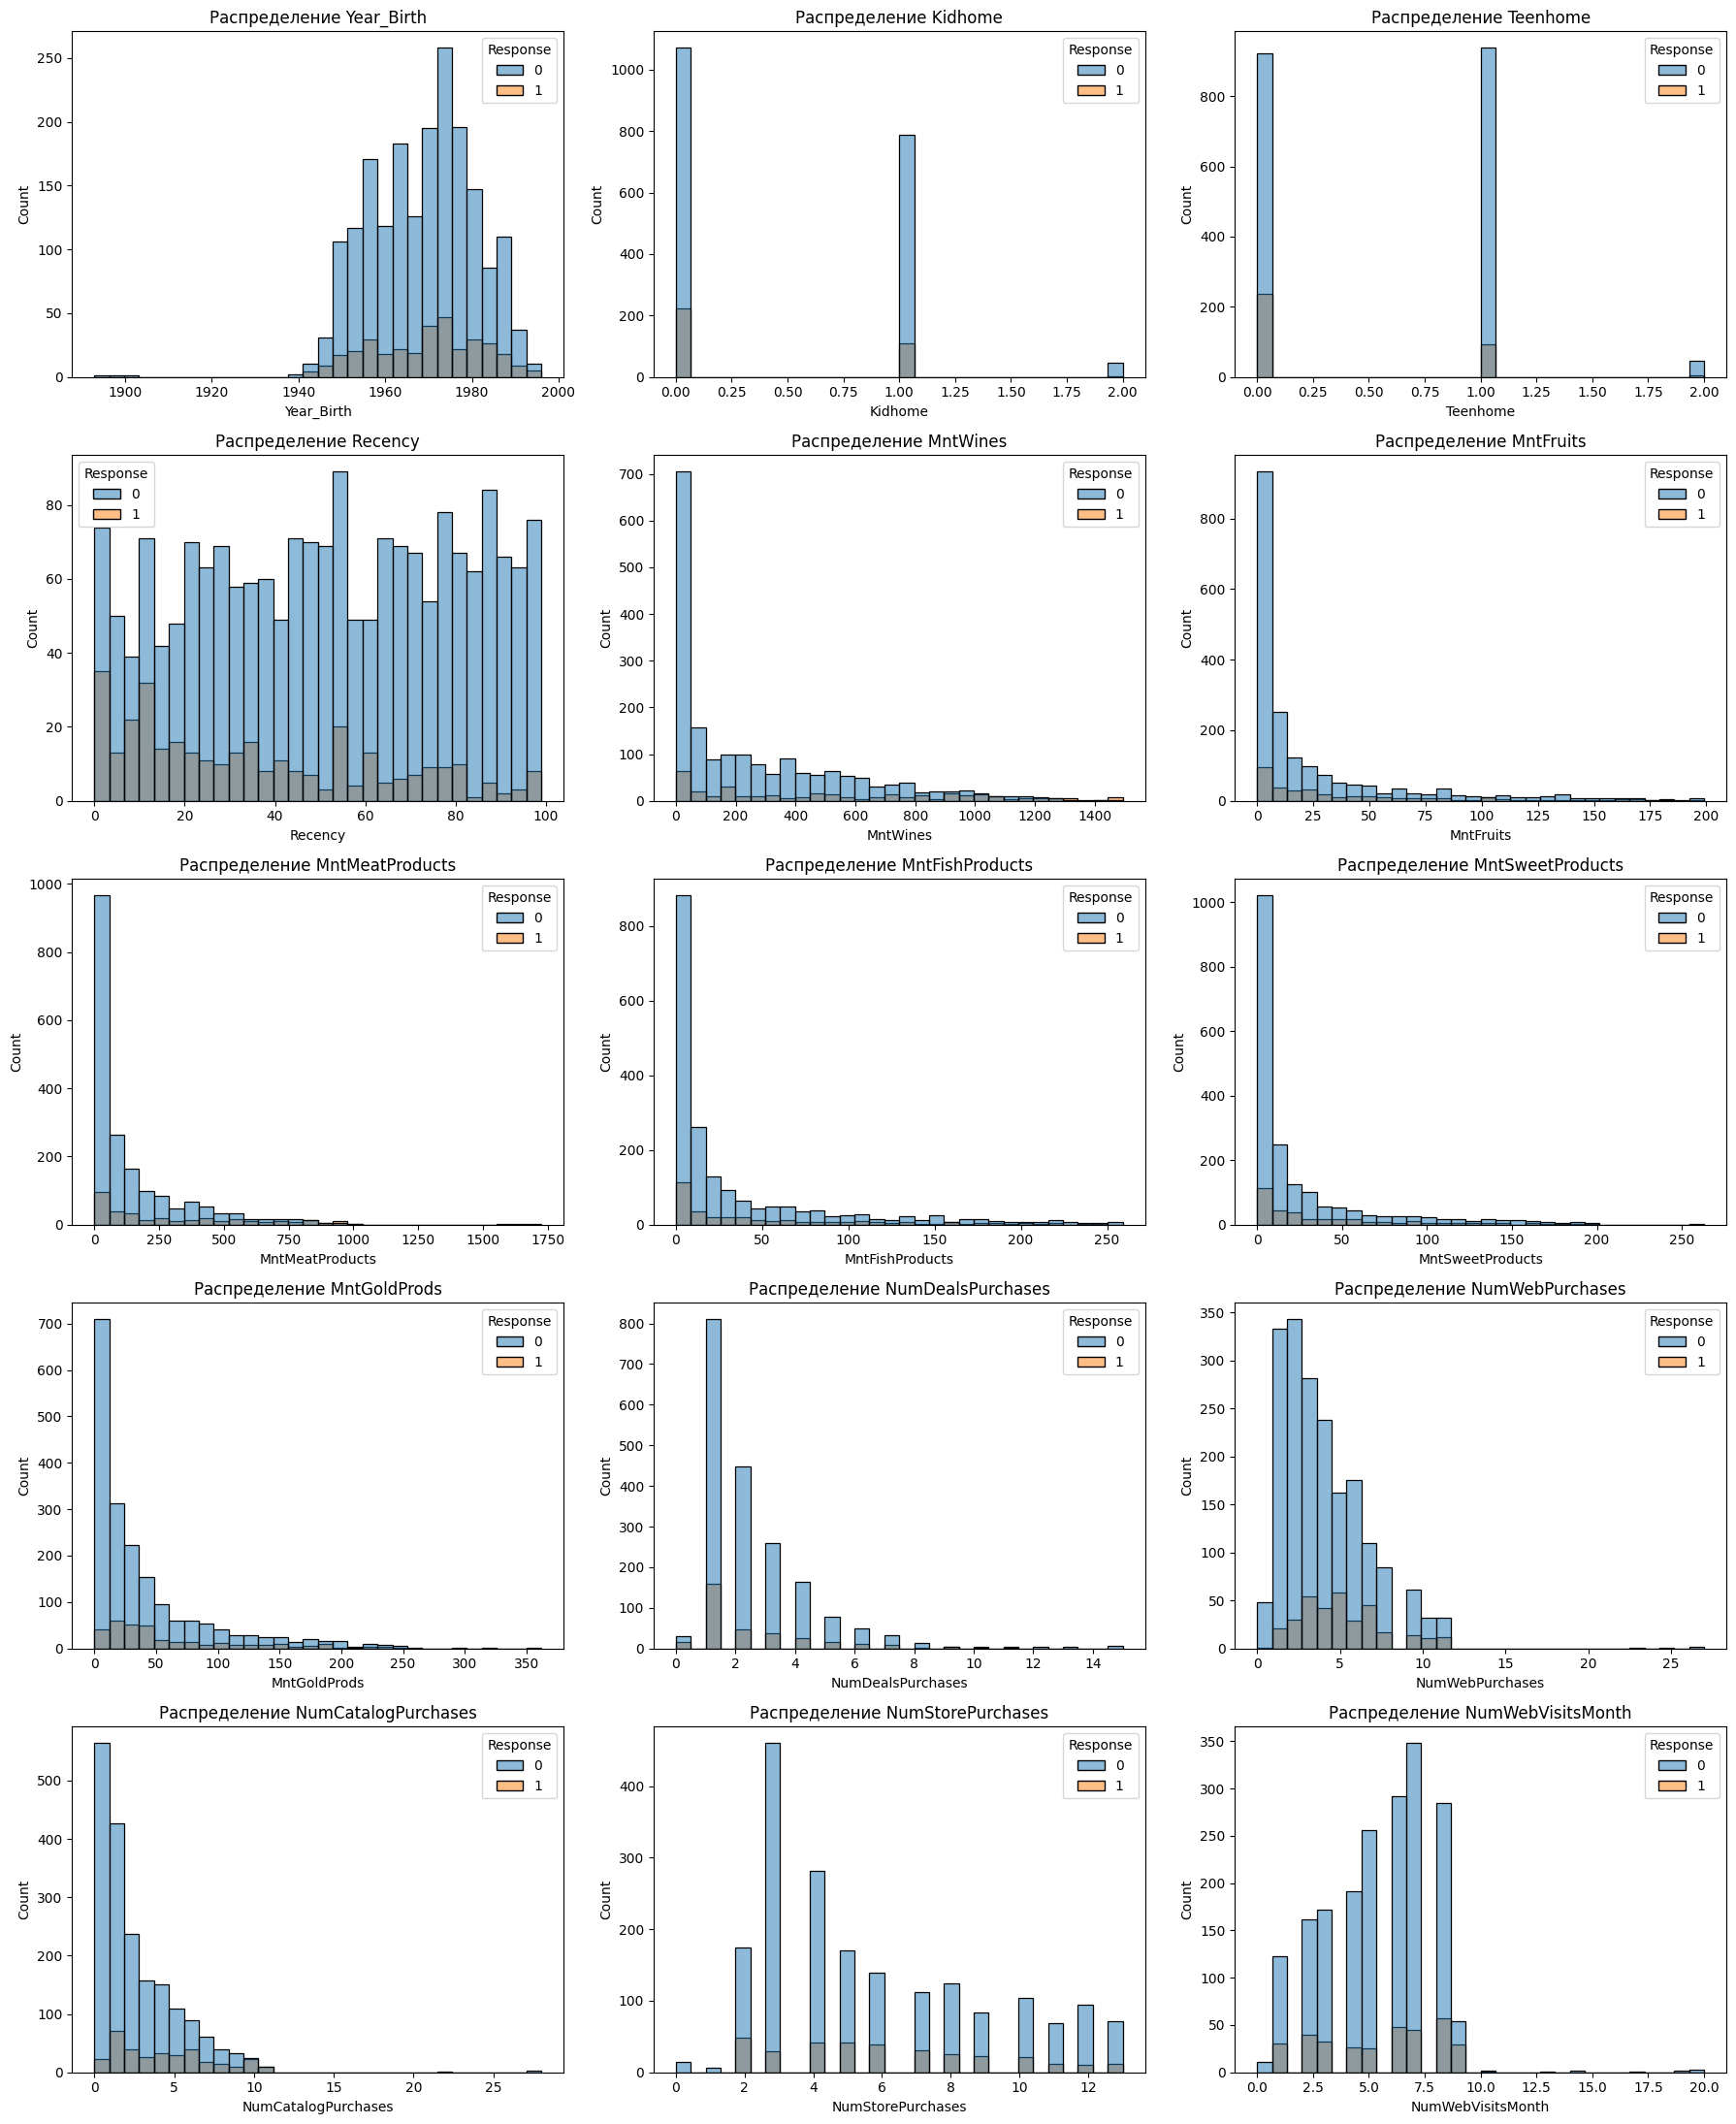

In [14]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22))

for var, ax in zip(int_columns, axes.flat):
    sns.histplot(df, x=var, hue='Response', bins=30, ax=ax)
    ax.set_title(f'Распределение {var}')

plt.tight_layout()
plt.show()

In [15]:
df.groupby(['Response'])[['Income', 'Teenhome', 'Kidhome']].describe()

Income                                                        \
           count          mean           std     min      25%      50%   
Response                                                                 
0         1883.0  50839.132767  25252.804747  1730.0  34421.0  50150.0   
1          333.0  60209.675676  23194.080987  7500.0  39763.0  64090.0   

                            Teenhome            ...           Kidhome  \
              75%       max    count      mean  ...  75%  max   count   
Response                                        ...                     
0         66308.0  666666.0   1906.0  0.541448  ...  1.0  2.0  1906.0   
1         80589.0  105471.0    334.0  0.305389  ...  1.0  2.0   334.0   

                                                       
              mean       std  min  25%  50%  75%  max  
Response                                               
0         0.462225  0.544975  0.0  0.0  0.0  1.0  2.0  
1         0.341317  0.487347  0.0  0.0  0.0  1.0  2.0  

[2 rows x 24 columns]

In [16]:
df.select_dtypes(exclude='number').columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

Теперь построим графики бинарных и категориальных переменных.

<Axes: xlabel='Response', ylabel='count'>

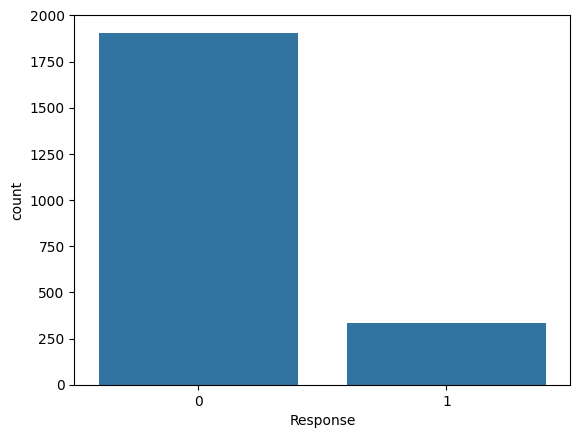

In [17]:
sns.countplot(data=df, x = 'Response')

In [18]:
categorical_variables = ['Education', 'Marital_Status']

In [19]:
bool_variables = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

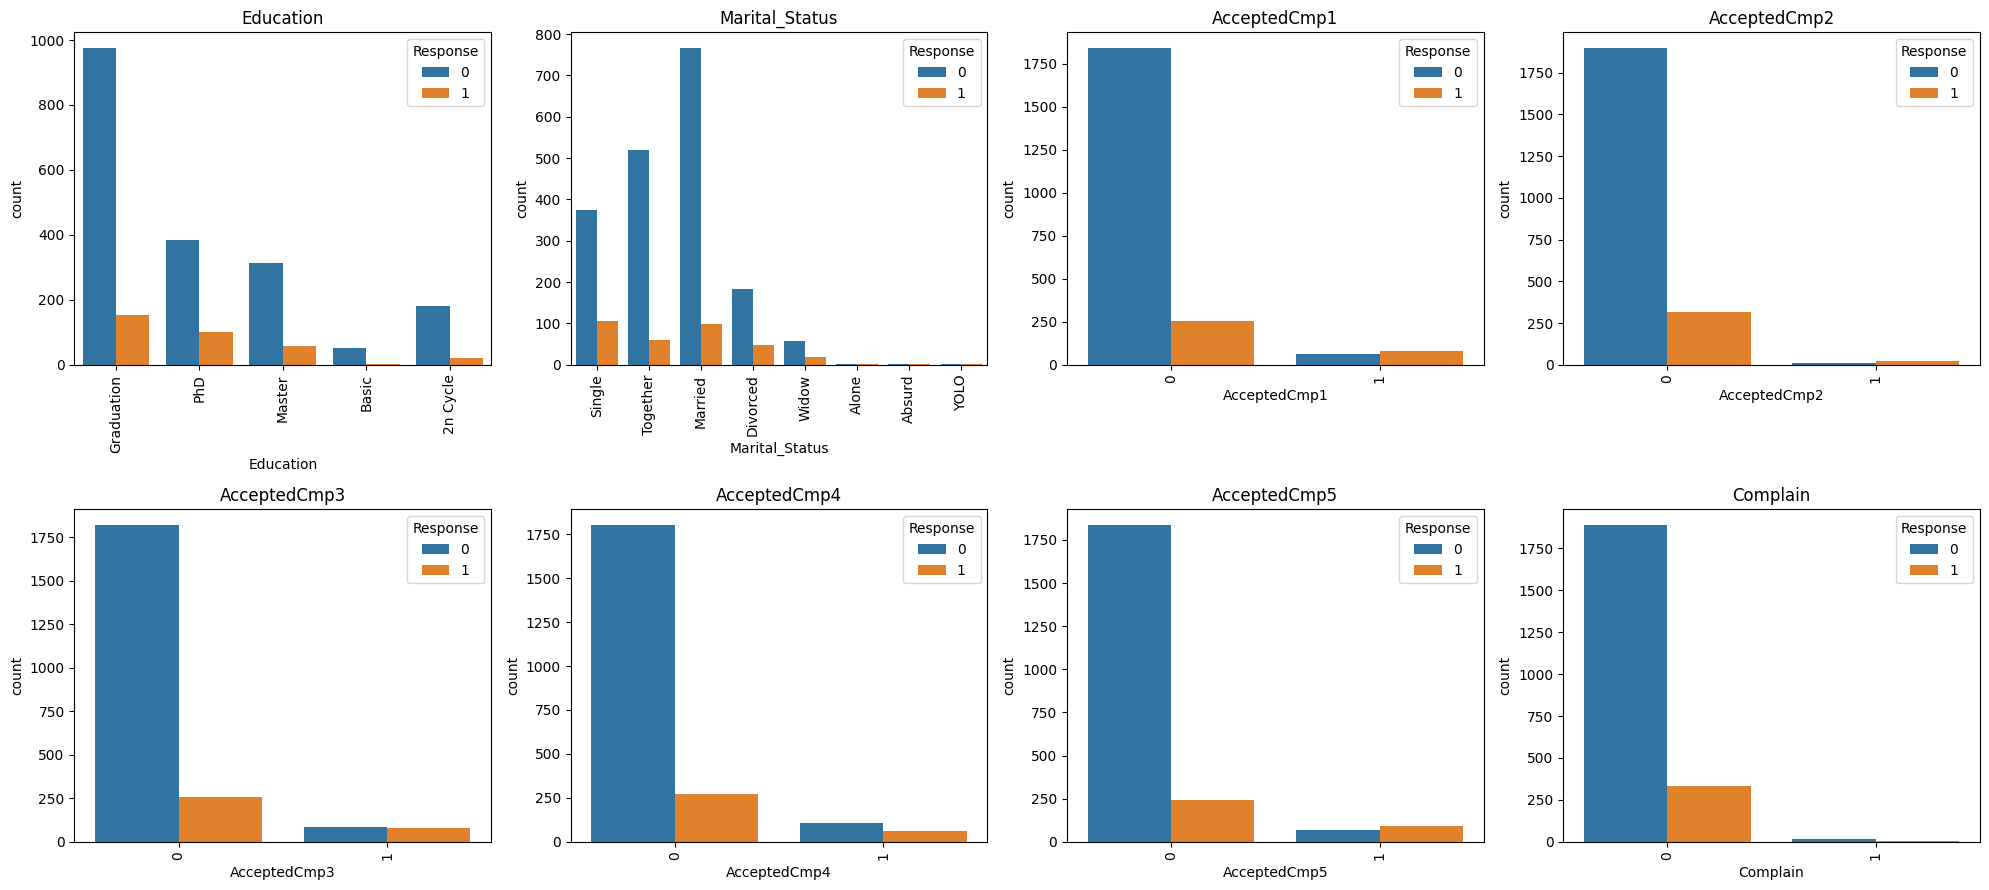

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for var, ax in zip(categorical_variables + bool_variables, axes.flat):
    sns.countplot(data=df, x=var, hue='Response', ax=ax)
    ax.set_title(var)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [21]:
df.groupby(['Marital_Status'])['ID'].count()

,ID
Marital_Status,
Absurd,2
Alone,3
Divorced,232
Married,864
Single,480
Together,580
Widow,77
YOLO,2


Посмотрим на "необычные" значения переменной `Marital_Status`.

In [22]:
df[(df['Marital_Status'] == 'Absurd') | (df['Marital_Status'] == 'YOLO')]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
2093,7734,1993,Graduation,Absurd,79244.0,0,0,2012-12-19,58,471,...,10,7,1,0,0,1,1,0,0,1
2134,4369,1957,Master,Absurd,65487.0,0,0,2014-01-10,48,240,...,5,6,2,0,0,0,0,0,0,0
2177,492,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,0
2202,11133,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,1


In [23]:
df['Marital_Status']  = np.where(df['Marital_Status'].isin(['Absurd', 'YOLO', 'Alone']), 'Single', df['Marital_Status'])

In [24]:
df.groupby(['Marital_Status'])['ID'].count()

,ID
Marital_Status,
Divorced,232
Married,864
Single,487
Together,580
Widow,77


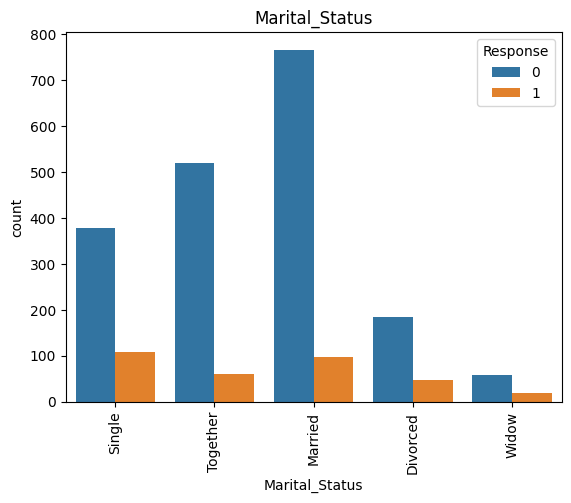

In [25]:
sns.countplot(data=df, x = 'Marital_Status', hue = 'Response')
plt.title('Marital_Status')
plt.xticks(rotation=90)
plt.show()

Посмотрим на доли откликнувшихся в разрезе нескольких признаков: участия во 2-й кампании, образования, семейного положения и количества маленьких детей:

In [26]:
df.groupby(['AcceptedCmp2'])[['Response']].agg(['count', 'mean'])

Response          
                count      mean
AcceptedCmp2                   
0                2210  0.142081
1                  30  0.666667

In [27]:
df.groupby(['Education'])[['Response']].agg(['count', 'mean'])

Response          
              count      mean
Education                    
2n Cycle        203  0.108374
Basic            54  0.037037
Graduation     1127  0.134871
Master          370  0.154054
PhD             486  0.207819

In [28]:
df.groupby(['Marital_Status'])[['Response']].agg(['count', 'mean'])

Response          
                  count      mean
Marital_Status                   
Divorced            232  0.206897
Married             864  0.113426
Single              487  0.223819
Together            580  0.103448
Widow                77  0.246753

In [29]:
df.groupby(['Kidhome'])[['Response']].agg(['count', 'mean'])

Response          
           count      mean
Kidhome                   
0           1293  0.171694
1            899  0.122358
2             48  0.041667

Построим boxplot-ы некоторых числовых переменных для каждого значения целевой переменной.

<Axes: xlabel='Response', ylabel='Income'>

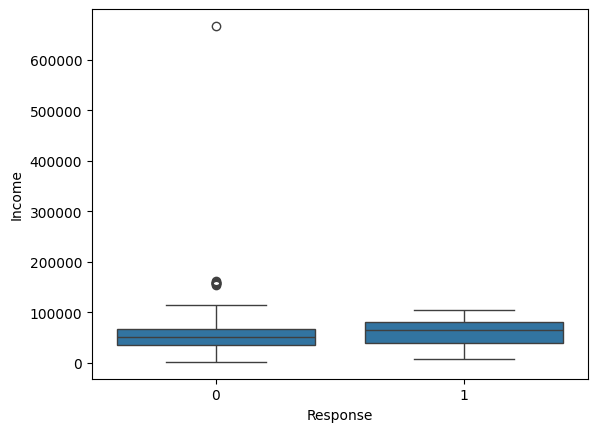

In [30]:
sns.boxplot(data=df, y = 'Income', x = 'Response')

Логистическая регрессия, которую мы далее рассмотрим, как и большинство моделей, работает только с числовыми признаками. Поэтому категориальные переменные нужно закодировать. Воспользуемся методом One-Hot Encoding.

One-Hot Encoding — это метод кодирования категориальных переменных, который преобразует каждую категорию в отдельный бинарный столбец.

В библиотеке pandas для One-Hot Encoding используется функция `pd.get_dummies()`. Для каждого категориального столбца она создает новые бинарные столбцы, соответствующие уникальным значениям этого столбца. Каждый бинарный столбец содержит 1 (True) или 0 (False) в зависимости от принадлежности записи к данной категории.

Параметр `drop_first=True` удаляет столбец для первой по алфавиту категории. Если оставить все столбцы, их сумма в каждой строке всегда равна 1, то есть они линейно выражают константу (свободный член модели). Это называется ловушкой дамми-переменных: признаки становятся линейно зависимыми.

In [31]:
data = pd.get_dummies(df, columns = ['Education', 'Marital_Status'], drop_first=True)

Посмотрим, что получилось:

In [32]:
data.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,0,1,False,True,False,False,False,True,False,False
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,False,True,False,False,False,True,False,False
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,False,True,False,False,False,False,True,False
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,False,True,False,False,False,False,True,False
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,False,False,False,True,True,False,False,False


In [33]:
data.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow'],
      dtype='object')

Из столбца `Education` (5 категорий) получилось 4 новых столбца: `Education_Basic`, `Education_Graduation`, `Education_Master`, `Education_PhD`.

Категория `2n Cycle` стала **базовой**: у клиентов с этим образованием все четыре столбца равны False. Веса модели при остальных столбцах будут показывать отличие от этой базовой категории. Так же для `Marital_Status` базовой стала категория `Divorced`.

In [34]:
df[['ID', 'Education']].head(1)

,ID,Education
0,5524,Graduation


In [35]:
data[['ID', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD']].head(1)

,ID,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,False,True,False,False


Удалим строки с пропусками в `Income` и выбросы по доходу: оставим клиентов с доходом не выше 99,5%-квантиля.

*Замечание: здесь мы чистим данные до разбиения на обучающую и тестовую выборки, то есть квантиль считается в том числе по будущим тестовым объектам. В учебном примере это допустимо, но в реальной задаче порог для выбросов лучше считать только по обучающей выборке.*

In [36]:
data.dropna(subset=['Income'], inplace = True)

In [37]:
data = data[(data['Income'] <= data['Income'].quantile(0.995))]

<Axes: xlabel='Response', ylabel='Income'>

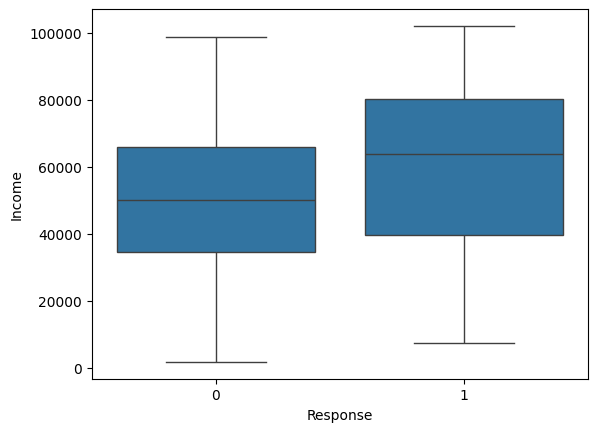

In [38]:
sns.boxplot(data=data, y = 'Income', x = 'Response')

Из поля `Dt_Customer` получим количество дней от даты, когда клиент начал пользоваться услугами компании, до 1 января 2015 года.
Из года рождения получим возраст на ту же дату.

Почему не от сегодняшней даты? Данные собраны в 2014 году. Если считать от сегодняшнего дня, ко всем значениям прибавится одинаковая большая константа, а возраст клиентов не будет соответствовать моменту кампании. Посмотрим на диапазон дат:

In [39]:
pd.to_datetime(data['Dt_Customer']).agg(['min', 'max'])

,Dt_Customer
min,2012-07-30
max,2014-06-29


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2204 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2204 non-null   int64  
 1   Year_Birth               2204 non-null   int64  
 2   Income                   2204 non-null   float64
 3   Kidhome                  2204 non-null   int64  
 4   Teenhome                 2204 non-null   int64  
 5   Dt_Customer              2204 non-null   object 
 6   Recency                  2204 non-null   int64  
 7   MntWines                 2204 non-null   int64  
 8   MntFruits                2204 non-null   int64  
 9   MntMeatProducts          2204 non-null   int64  
 10  MntFishProducts          2204 non-null   int64  
 11  MntSweetProducts         2204 non-null   int64  
 12  MntGoldProds             2204 non-null   int64  
 13  NumDealsPurchases        2204 non-null   int64  
 14  NumWebPurchases          2204

In [41]:
data['days'] = (pd.Timestamp('2015-01-01') - pd.to_datetime(data['Dt_Customer'])).dt.days
data = data.drop(['Dt_Customer'], axis=1)

In [42]:
data['Year_Birth'].min()

1893

Три клиента родились раньше 1901 года, это явные ошибки в данных. Удалим клиентов, родившихся раньше 1940 года.

In [43]:
print((data['Year_Birth'] < 1940).sum(), 'клиента(ов) будет удалено')
data = data[data['Year_Birth'] >= 1940]

3 клиента(ов) будет удалено


In [44]:
data['Age'] = 2015 - data['Year_Birth']
data = data.drop(['Year_Birth'], axis=1)

In [45]:
data.head()

,ID,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,days,Age
0,5524,58138.0,0,0,58,635,88,546,172,88,...,False,True,False,False,False,True,False,False,849,58
1,2174,46344.0,1,1,38,11,1,6,2,1,...,False,True,False,False,False,True,False,False,299,61
2,4141,71613.0,0,0,26,426,49,127,111,21,...,False,True,False,False,False,False,True,False,498,50
3,6182,26646.0,1,0,26,11,4,20,10,3,...,False,True,False,False,False,False,True,False,325,31
4,5324,58293.0,1,0,94,173,43,118,46,27,...,False,False,False,True,True,False,False,False,347,34


In [46]:
data.drop(['ID'], axis=1, inplace=True) # удалим идентификатор клиента - для анализа он не нужен

Теперь построим матрицу корреляций между числовыми признаками, которые пойдут в модель, и целевой переменной.
Коэффициент корреляции Пирсона измеряется по шкале от -1 до 1: 0 — отсутствие линейной связи, значения, близкие к -1, — сильная отрицательная линейная связь, близкие к 1 — сильная положительная линейная связь.

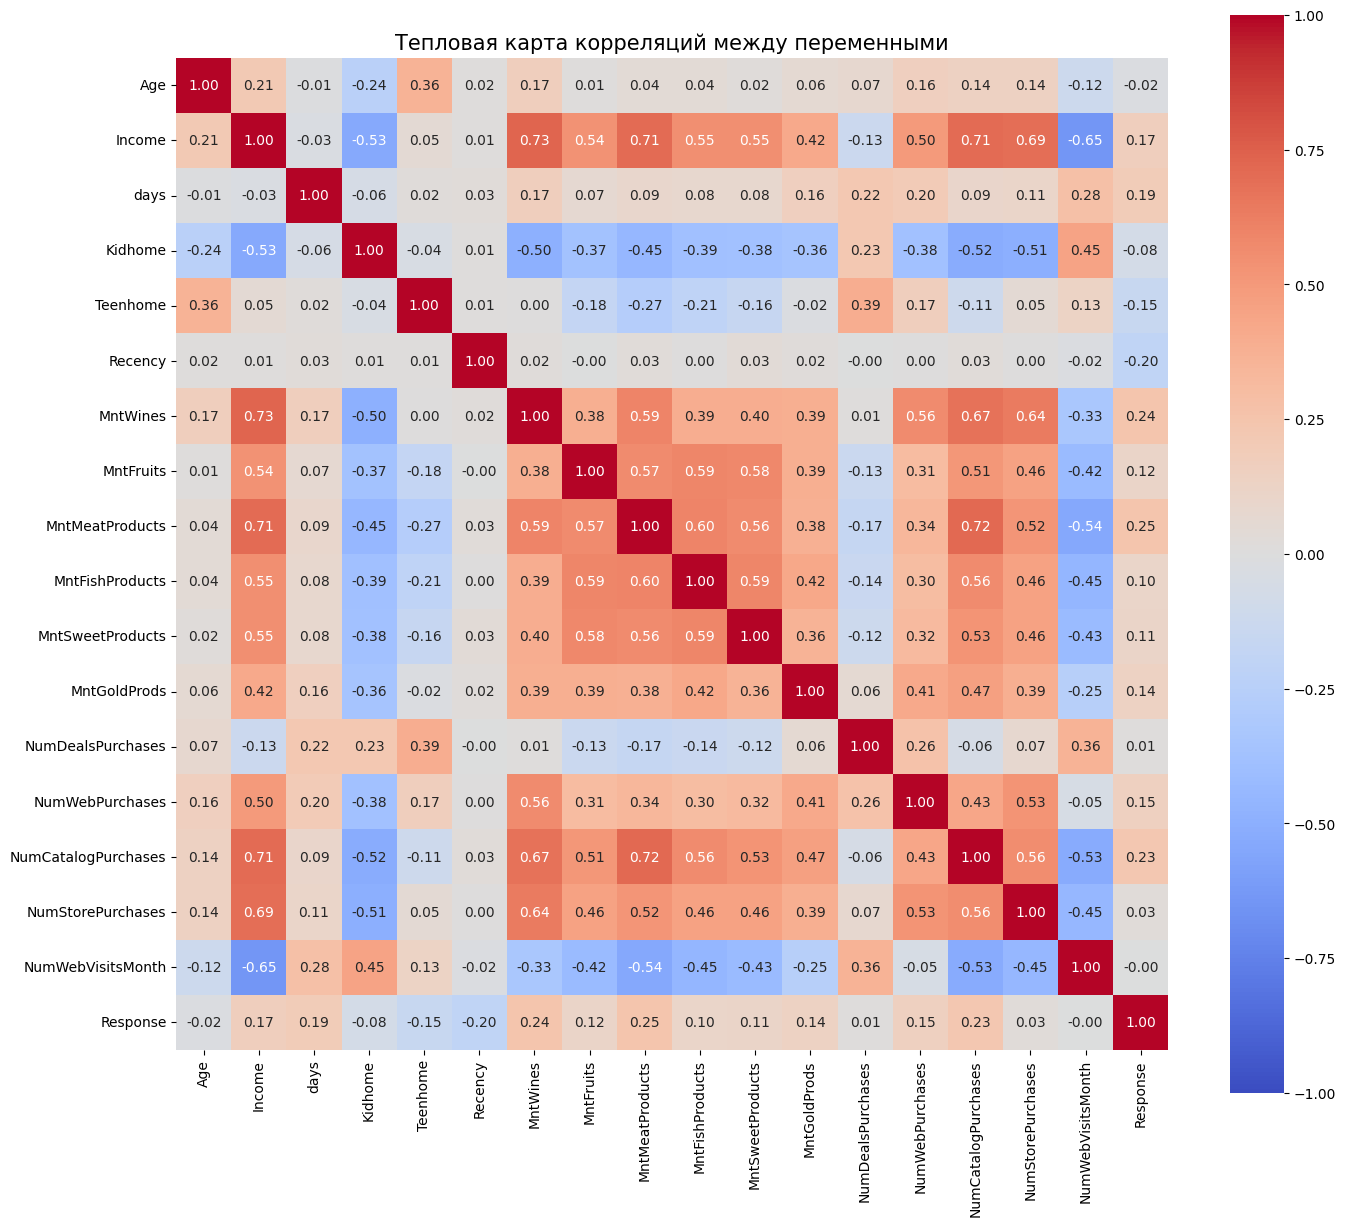

In [47]:
corr_columns = ['Age', 'Income', 'days', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
                'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
                'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
                'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response']
correlation_matrix = data[corr_columns].corr()

# Строим тепловую карту (heatmap) корреляций
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, vmin=-1, vmax=1)
plt.title('Тепловая карта корреляций между переменными', fontsize=15)
plt.yticks(rotation=0)
plt.show()

## Логистическая регрессия

Попробуем научиться предсказывать отклик клиента на кампанию с помощью логистической регрессии.

$ P(Response = 1) = \sigma(w_0+w_1*Income + ...) $,
где $ \sigma(x) = \frac{1}{1+e^{(-x)}} $

In [48]:
X_columns = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'days']

In [49]:
lr = LogisticRegression(solver='liblinear')
X = data.drop(['Response'], axis=1)
y = data['Response']
# stratify=y: доля откликнувшихся одинакова в обучающей и тестовой выборках
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [50]:
ytrain.value_counts()

,count
Response,
0,1309
1,231


In [51]:
Xtrain = Xtrain[X_columns]
Xtest = Xtest[X_columns]
lr.fit(Xtrain, ytrain)
pred_train = lr.predict(Xtrain)
pred_test = lr.predict(Xtest)
pred_train_prob = lr.predict_proba(Xtrain)
pred_test_prob = lr.predict_proba(Xtest)

*Обратите внимание: признаки пока не стандартизированы. Доход измеряется десятками тысяч, а количество детей — единицами. Посмотрим, к чему это приведет.*

#### Метрики качества модели

##### **Accuracy, Precision, Recall, F1**

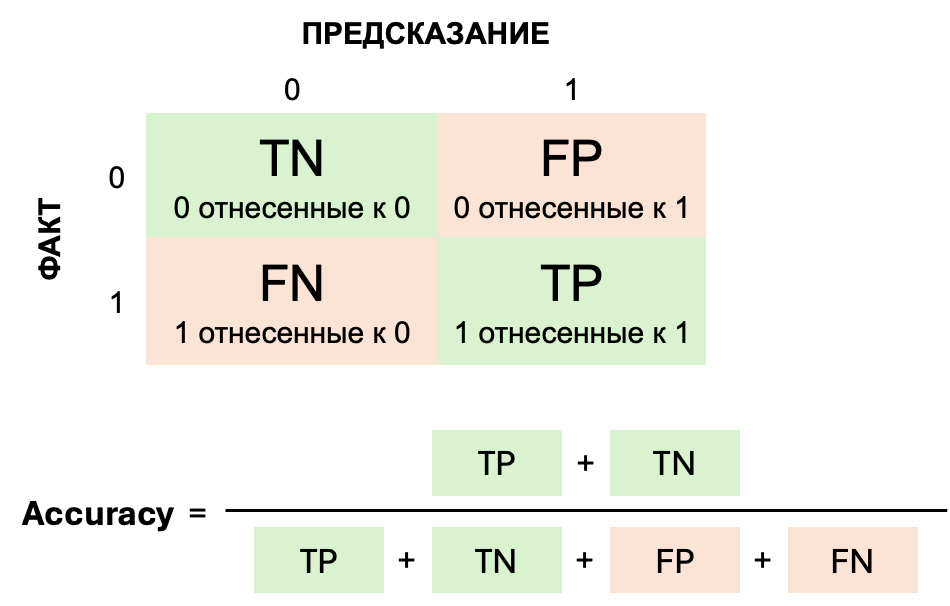

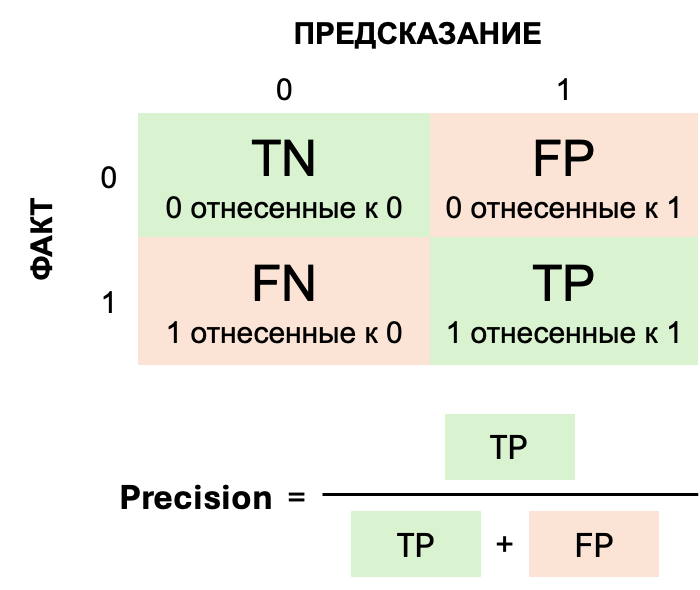

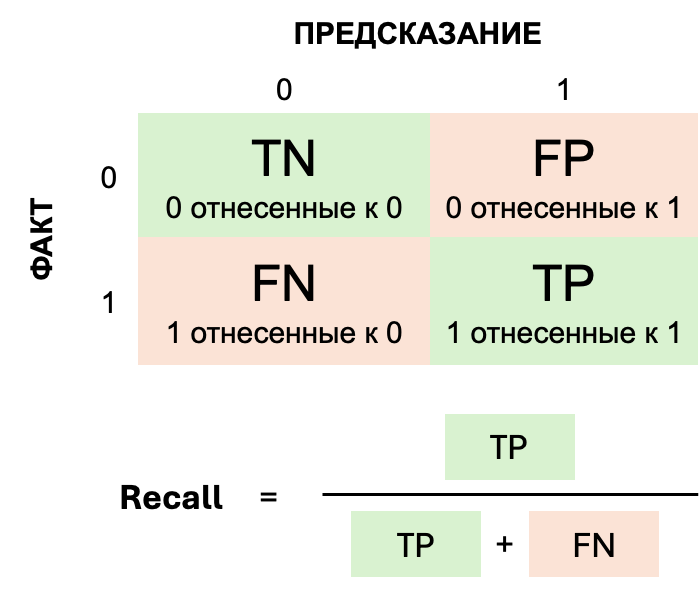

In [52]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_prob[:, 1]), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_prob[:, 1]), 3))

Accuracy score, train: 0.852
Recall score, train: 0.139
Precision score, train: 0.525
ROC AUC, train: 0.785

Accuracy score, test: 0.868
Recall score, test: 0.242
Precision score, test: 0.667
ROC AUC, test: 0.818


Доля откликнувшихся в выборке около 15%. Accuracy на тесте около 0.87 выглядит прилично, но модель находит только около четверти откликнувшихся клиентов (recall).

**Вопрос:** Какая модель дала бы accuracy около 0.85, вообще ничего не умея? Проверим это ниже.

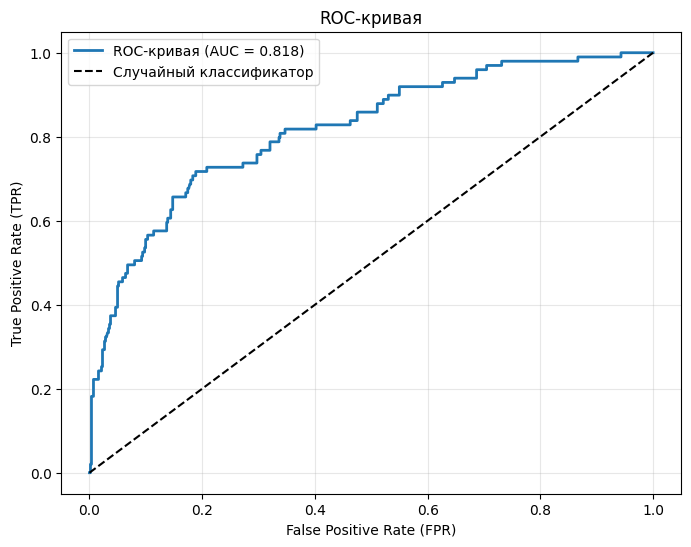

In [53]:
fpr, tpr, thresholds = roc_curve(ytest,  pred_test_prob[:, 1])
auc = roc_auc_score(ytest, pred_test_prob[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

PR AUC (Average Precision) = 0.520
Доля положительного класса в тесте = 0.150


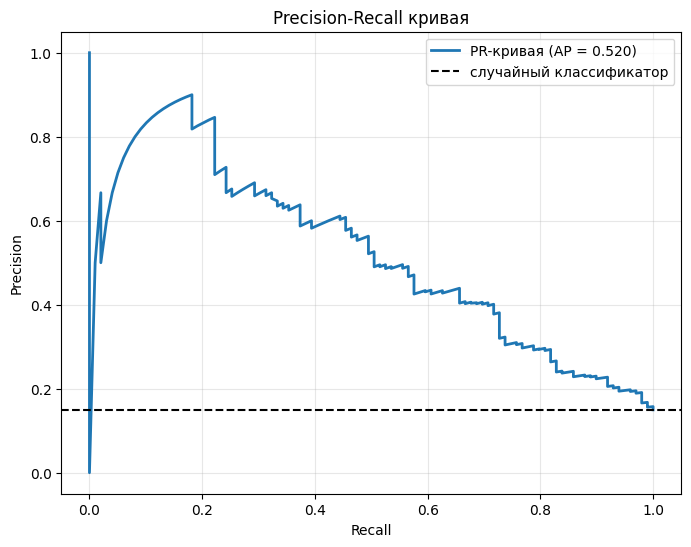

In [54]:
precision, recall, thresholds = precision_recall_curve(ytest, pred_test_prob[:, 1])

pr_auc = average_precision_score(ytest, pred_test_prob[:, 1])
print(f"PR AUC (Average Precision) = {pr_auc:.3f}")
print(f"Доля положительного класса в тесте = {ytest.mean():.3f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR-кривая (AP = {pr_auc:.3f})', linewidth=2)
plt.axhline(ytest.mean(), linestyle='--', c='k', label='случайный классификатор')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Average Precision (AP) — это почти площадь под PR-кривой: sklearn считает ее как сумму прямоугольников, а не по методу трапеций, поэтому значения могут немного отличаться от `auc(recall, precision)`.

В отличие от ROC AUC, у случайного классификатора PR AUC равна не 0.5, а доле положительного класса. Поэтому AP нужно сравнивать с этой долей, а не с 0.5.

Наивные предсказания:

In [55]:
pred_train_0 = np.zeros(Xtrain.shape[0]) # никто не откликнется
pred_test_0 = np.zeros(Xtest.shape[0])
pred_train_2 = Xtrain['AcceptedCmp2'] # отклик будет как в компании 2
pred_test_2 = Xtest['AcceptedCmp2']

In [56]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train_0), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train_0), 3))
# zero_division=0: модель ни разу не предсказала 1, precision формально не определена
print('Precision score, train:', round(precision_score(ytrain, pred_train_0, zero_division=0), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test_0), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_0), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_0, zero_division=0), 3))

Accuracy score, train: 0.85
Recall score, train: 0.0
Precision score, train: 0.0

Accuracy score, test: 0.85
Recall score, test: 0.0
Precision score, test: 0.0


In [57]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train_2), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train_2), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train_2), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_2), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test_2), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_2), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_2), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_2), 3))

Accuracy score, train: 0.853
Recall score, train: 0.048
Precision score, train: 0.611
ROC AUC, train: 0.521

Accuracy score, test: 0.858
Recall score, test: 0.081
Precision score, test: 0.727
ROC AUC, test: 0.538


Стандартизируем признаки и обучим модель заново:

In [58]:
scaler = StandardScaler()
scaler.fit(Xtrain)
Xtrain_norm = scaler.transform(Xtrain)
Xtest_norm = scaler.transform(Xtest)
lr =  LogisticRegression(solver= 'liblinear')
lr.fit(Xtrain_norm, ytrain)
pred_train = lr.predict(Xtrain_norm)
pred_test = lr.predict(Xtest_norm)
pred_train_prob = lr.predict_proba(Xtrain_norm)
pred_test_prob = lr.predict_proba(Xtest_norm)

In [59]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_prob[:, 1]), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_prob[:, 1]), 3))

Accuracy score, train: 0.897
Recall score, train: 0.485
Precision score, train: 0.742
ROC AUC, train: 0.909

Accuracy score, test: 0.914
Recall score, test: 0.576
Precision score, test: 0.792
ROC AUC, test: 0.928


Качество заметно выросло, хотя модель та же самая. Две причины:
1. `LogisticRegression` в sklearn по умолчанию использует L2-регуляризацию. Штраф одинаков для всех весов, а веса у признаков разного масштаба имеют разный порядок. Без стандартизации регуляризация штрафует признаки несправедливо.
2. Численная оптимизация на признаках очень разного масштаба сходится хуже.

**Вывод:** для линейных моделей с регуляризацией признаки нужно стандартизировать.

## Матрица ошибок, F1 и выбор порога

По умолчанию `predict` относит объект к классу 1, если предсказанная вероятность больше 0.5. Но порог 0.5 ничем не выделен: при сильном дисбалансе классов модель редко набирает такую уверенность для редкого класса.

Посмотрим на матрицу ошибок и F1-меру при пороге 0.5:

F1 score, test: 0.667


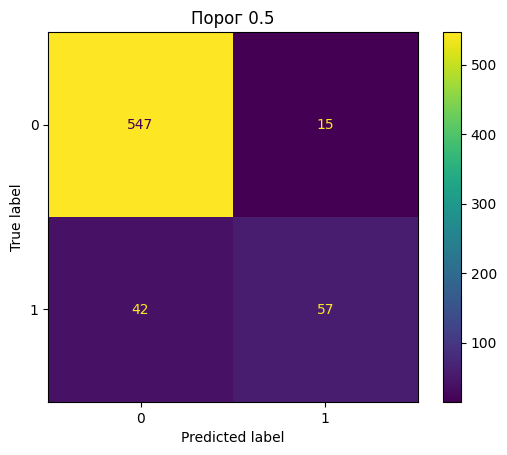

In [60]:
print('F1 score, test:', round(f1_score(ytest, pred_test), 3))
ConfusionMatrixDisplay.from_predictions(ytest, pred_test)
plt.title('Порог 0.5')
plt.show()

Подберем порог, при котором F1 максимальна.

**Важно:** порог — это тоже гиперпараметр, поэтому подбирать его на тестовой выборке нельзя, иначе оценка качества на тесте станет оптимистичной. Подберем его на обучающей выборке по предсказаниям кросс-валидации (`cross_val_predict`): каждый объект получает вероятность от модели, которая не видела его при обучении.

Стандартизацию положим внутрь пайплайна, чтобы на каждом фолде скейлер обучался только на обучающей части.

F1 на кросс-валидации при пороге 0.50: 0.538
Лучший порог: 0.23, F1 на кросс-валидации: 0.597


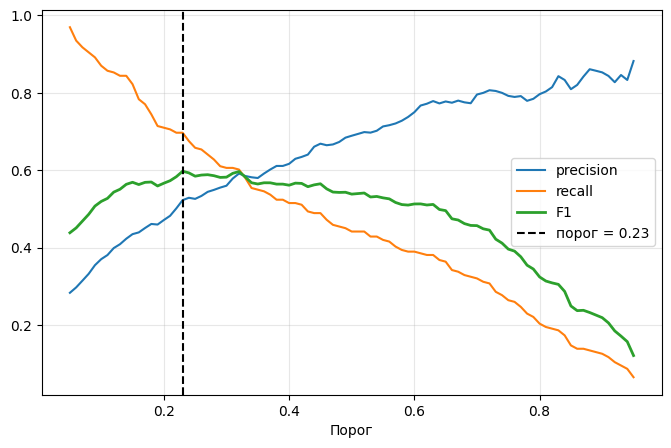

In [61]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear'))
oof_prob = cross_val_predict(pipe, Xtrain, ytrain, cv=5, method='predict_proba')[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(ytrain, (oof_prob >= t).astype(int)) for t in thresholds]
precs = [precision_score(ytrain, (oof_prob >= t).astype(int), zero_division=0) for t in thresholds]
recs = [recall_score(ytrain, (oof_prob >= t).astype(int)) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f'F1 на кросс-валидации при пороге 0.50: {f1_score(ytrain, (oof_prob >= 0.5).astype(int)):.3f}')
print(f'Лучший порог: {best_t:.2f}, F1 на кросс-валидации: {max(f1s):.3f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precs, label='precision')
plt.plot(thresholds, recs, label='recall')
plt.plot(thresholds, f1s, label='F1', linewidth=2)
plt.axvline(best_t, linestyle='--', c='k', label=f'порог = {best_t:.2f}')
plt.xlabel('Порог')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Применим найденный порог к вероятностям модели на тестовой выборке:

Accuracy score, test: 0.882
Recall score, test: 0.768
Precision score, test: 0.58
F1 score, test: 0.661


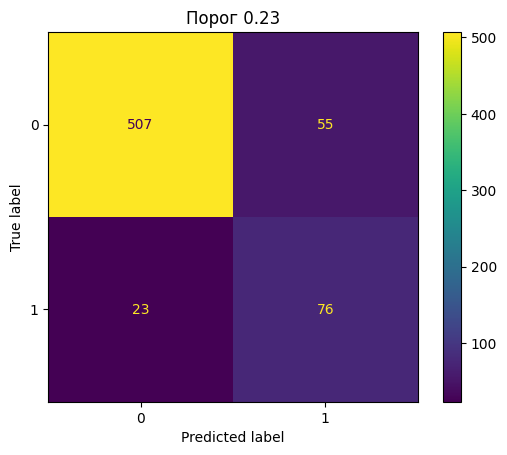

In [62]:
pred_test_t = (pred_test_prob[:, 1] >= best_t).astype(int)

print('Accuracy score, test:', round(accuracy_score(ytest, pred_test_t), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_t), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_t), 3))
print('F1 score, test:', round(f1_score(ytest, pred_test_t), 3))

ConfusionMatrixDisplay.from_predictions(ytest, pred_test_t)
plt.title(f'Порог {best_t:.2f}')
plt.show()

**Вопрос:** Почему ROC AUC при смене порога не изменилась?

### Взвешивание классов

Другой способ бороться с дисбалансом — `class_weight='balanced'`. Ошибки на редком классе получают в функции потерь больший вес, обратно пропорциональный частоте класса. Модель начинает выдавать для редкого класса более высокие вероятности.

In [63]:
lr_bal = LogisticRegression(solver='liblinear', class_weight='balanced')
lr_bal.fit(Xtrain_norm, ytrain)
pred_test_bal = lr_bal.predict(Xtest_norm)
pred_test_bal_prob = lr_bal.predict_proba(Xtest_norm)

print('Accuracy score, test:', round(accuracy_score(ytest, pred_test_bal), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_bal), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_bal), 3))
print('F1 score, test:', round(f1_score(ytest, pred_test_bal), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_bal_prob[:, 1]), 3))

Accuracy score, test: 0.832
Recall score, test: 0.848
Precision score, test: 0.467
F1 score, test: 0.602
ROC AUC, test: 0.922


## Выводы

1. Accuracy при дисбалансе классов обманчива: константная модель «никто не откликнется» дает accuracy 0.85.
2. Стандартизация признаков сильно улучшила логистическую регрессию с регуляризацией: ROC AUC на тесте выросла с 0.82 до 0.93.
3. Порог 0.5 не обязателен. Порог, подобранный по F1 на кросс-валидации, заметно сдвинул баланс в сторону полноты: модель находит около 77% откликнувшихся вместо 58%, зато precision падает с 0.79 до 0.58. На кросс-валидации F1 выросла с 0.54 до 0.60, а на тесте почти не изменилась (0.67 и 0.66): тестовая выборка небольшая, около 100 откликнувшихся, и порог 0.5 на ней оказался удачным. Какой порог выбрать, решает бизнес: что дороже, лишний контакт с клиентом или пропущенный отклик.
4. `class_weight='balanced'` дает похожий эффект: recall растет, precision падает. ROC AUC почти не меняется, потому что она не зависит от порога и оценивает только упорядочивание объектов.

**Вопрос для обсуждения:** Контакт с клиентом стоит 3 условные единицы, а откликнувшийся клиент приносит 11 (это значения служебных полей `Z_CostContact` и `Z_Revenue`, которые мы удалили в начале). Как выбрать порог, который максимизирует прибыль, а не F1?